# 03 - KMeans Segmentation and Classical Computer Vision

## Objective

This notebook explores how classical computer vision techniques
can isolate diseased regions in plant leaves before deep learning.

We will implement:

- HSV color-space analysis
- Manual KMeans clustering
- Disease region segmentation
- Morphological cleanup
- Contour extraction
- Severity estimation

This notebook acts as a bridge between:

Classical Computer Vision
→ and →
Modern Deep Learning

We aim to understand how visual structure emerges statistically
inside image data.

# Why Segmentation Matters

Diseased leaves often contain:

- yellow patches
- brown lesions
- fungal spread
- texture irregularities

CNNs can benefit when:
- irrelevant background is removed
- disease regions are isolated
- noise is reduced

Segmentation helps focus the model on:
- meaningful regions
- pathological structure
- visual abnormalities

This concept appears in:
- medical imaging
- satellite segmentation
- autonomous driving
- OCR systems
- agricultural AI

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from glob import glob

from skimage import morphology
from sklearn.cluster import KMeans

# Load Image

OpenCV loads images in BGR format.
We convert to RGB for visualization consistency.

In [2]:
IMAGE_PATH = '../data/processed/tomato_subset/train/Tomato___Early_blight/ff422d28-d002-4382-80bf-30f78f66c677___RS_Erly.B 6492_flipTB.JPG'

image = cv2.imread(IMAGE_PATH)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image Shape:", image_rgb.shape)

Image Shape: (256, 256, 3)


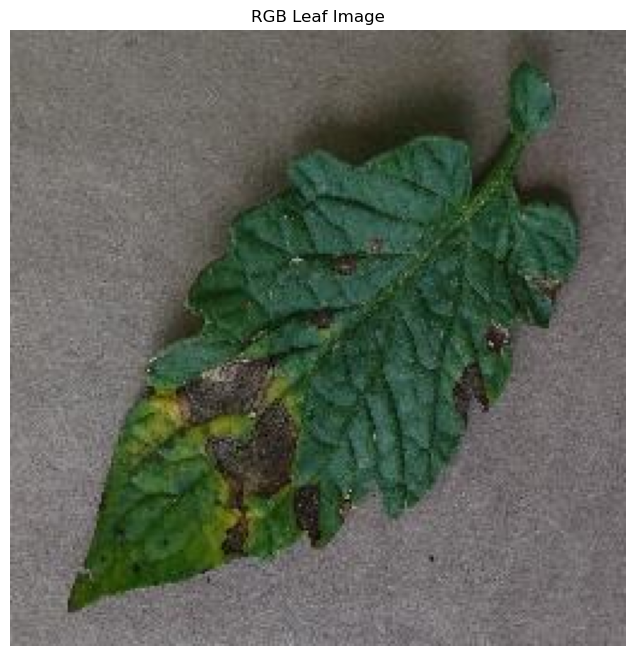

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("RGB Leaf Image")
plt.axis("off")

plt.show()

# HSV Visualization

HSV separates:
- Hue → color
- Saturation → purity
- Value → brightness

Disease regions often become easier to isolate in HSV.

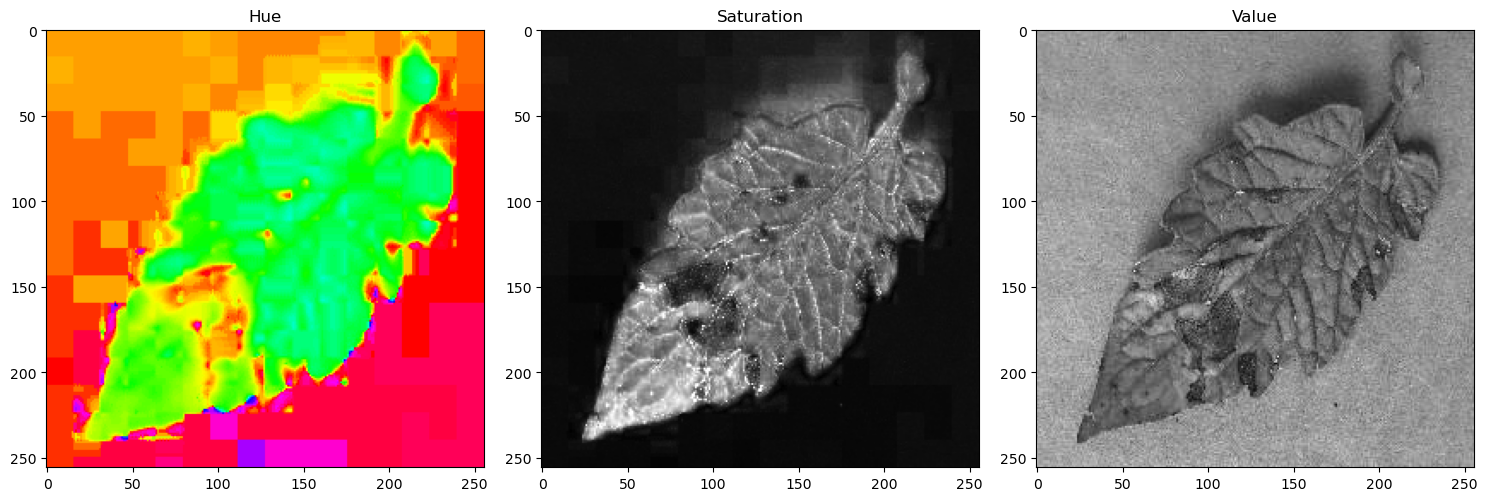

In [4]:
image_hsv = cv2.cvtColor(
    image_rgb,
    cv2.COLOR_RGB2HSV
)

h, s, v = cv2.split(image_hsv)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(h, cmap='hsv')
ax[0].set_title("Hue")

ax[1].imshow(s, cmap='gray')
ax[1].set_title("Saturation")

ax[2].imshow(v, cmap='gray')
ax[2].set_title("Value")

plt.tight_layout()

plt.show()

# Flatten Pixels

KMeans expects:
(N, Features)

We therefore convert image pixels into:
(number_of_pixels, RGB_features)

In [5]:
pixels = image_hsv.reshape((-1, 3))
pixels = np.float32(pixels)

print("Flattened Shape:", pixels.shape)

Flattened Shape: (65536, 3)


# Manual KMeans Clustering

We manually implement:
- centroid initialization
- distance computation
- cluster assignment
- centroid update
- convergence

In [ ]:
K = 3

np.random.seed(42)

random_idx = np.random.choice(
    len(pixels),
    K,
    replace=False
)

centroids = pixels[random_idx]


In [7]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)


for iteration in range(20):
    clusters = []
    # --------------------------------------------------------
    # ASSIGN PIXELS TO NEAREST CENTROID
    # --------------------------------------------------------
    for pixel in pixels:
        distances = []
        for centroid in centroids:
            d = euclidean_distance(
                pixel,
                centroid
            )
            distances.append(d)
        cluster = np.argmin(distances)
        clusters.append(cluster)
    clusters = np.array(clusters)

    # --------------------------------------------------------
    # UPDATE CENTROIDS
    # --------------------------------------------------------

    new_centroids = []
    for i in range(K):

        cluster_pixels = pixels[
            clusters == i
        ]

        # EMPTY CLUSTER CHECK
        if len(cluster_pixels) == 0:
            centroid = centroids[i]
        else:
            centroid = np.mean(
                cluster_pixels,
                axis=0
            )
        new_centroids.append(centroid)
        
    new_centroids = np.array(new_centroids)

    # --------------------------------------------------------
    # CONVERGENCE CHECK
    # --------------------------------------------------------

    if np.allclose(
        centroids,
        new_centroids
    ):

        print(f"Converged at iteration {iteration}")

        break

    centroids = new_centroids

Converged at iteration 9


# Cluster Visualization

Each pixel now belongs to:
- cluster 0
- cluster 1
- cluster 2

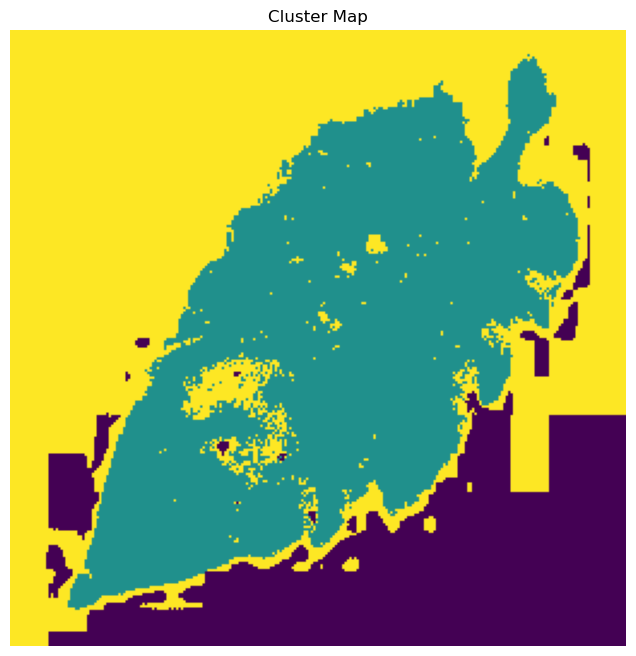

In [8]:
clustered = clusters.reshape(
    image_rgb.shape[:2]
)

plt.figure(figsize=(8,8))
plt.imshow(clustered, cmap='viridis')
plt.title("Cluster Map")
plt.axis("off")
plt.show()

# Reconstruct Segmented Image

Each cluster centroid represents:
a dominant color region.

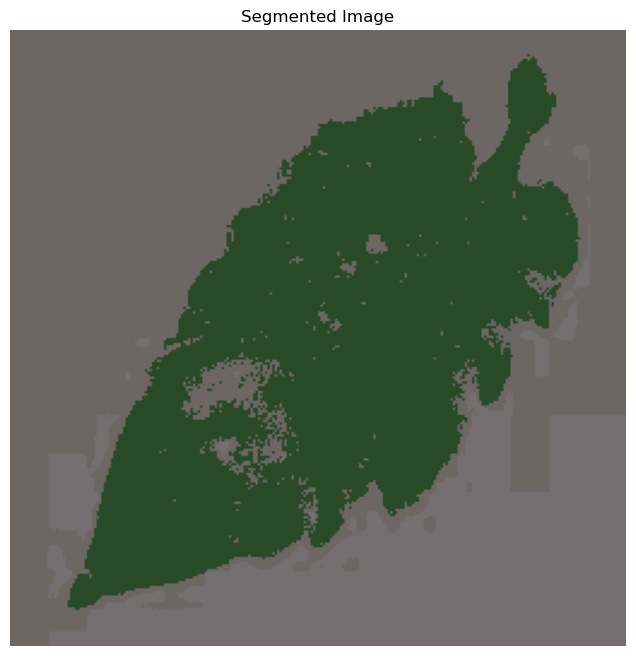

In [10]:
segmented = centroids[clusters]

segmented = segmented.reshape(
    image_hsv.shape
)

segmented_rgb = cv2.cvtColor(
    segmented.astype(np.uint8),
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(segmented_rgb)
plt.title("Segmented Image")
plt.axis("off")
plt.show()

# Disease Isolation

We select the cluster representing:
- brown lesions
- yellow infected regions

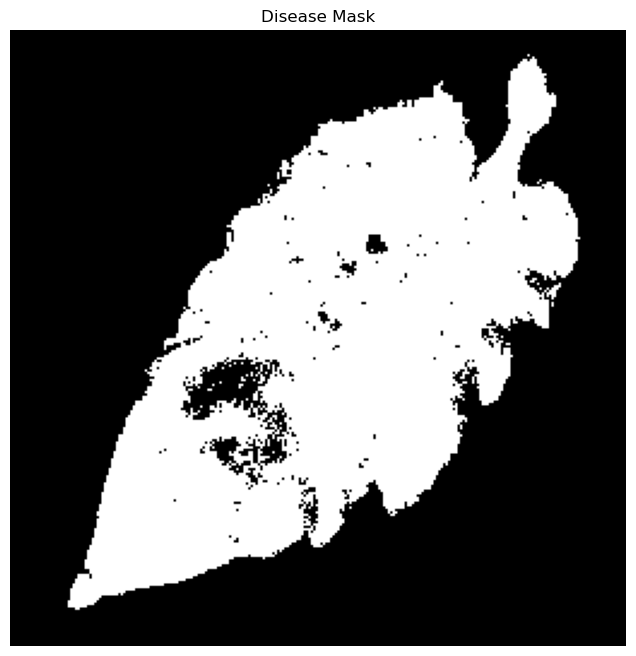

In [12]:
disease_cluster = 1

mask = (clustered == disease_cluster)

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap='gray')
plt.title("Disease Mask")
plt.axis("off")
plt.show()

# Morphological Cleanup

Removes:
- small noise
- tiny artifacts
- fragmented pixels

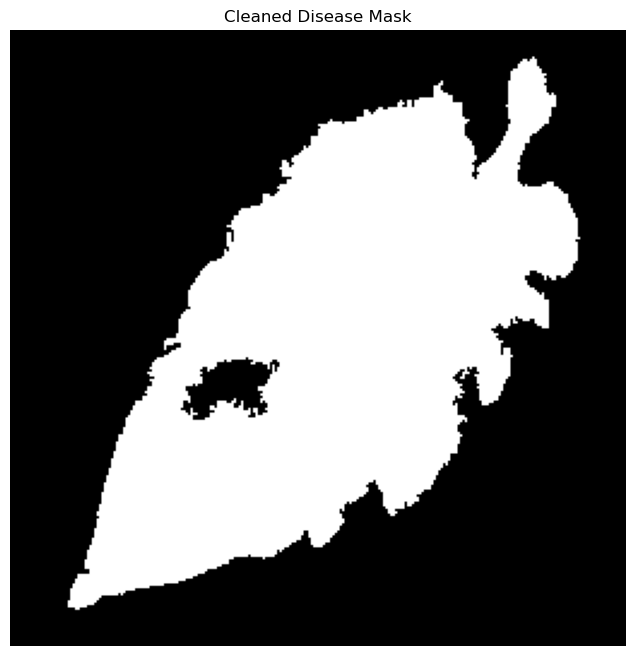

In [14]:
cleaned = morphology.remove_small_objects(mask, min_size=200)

cleaned = morphology.remove_small_holes(cleaned, area_threshold=300)

plt.figure(figsize=(8,8))
plt.imshow(cleaned, cmap='gray')
plt.title("Cleaned Disease Mask")
plt.axis("off")
plt.show()

# Contour Analysis

Contours reveal:
- lesion boundaries
- disease spread
- geometric structure

In [19]:
cleaned_uint8 = cleaned.astype(np.uint8)

contours, _ = cv2.findContours(
    cleaned_uint8,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

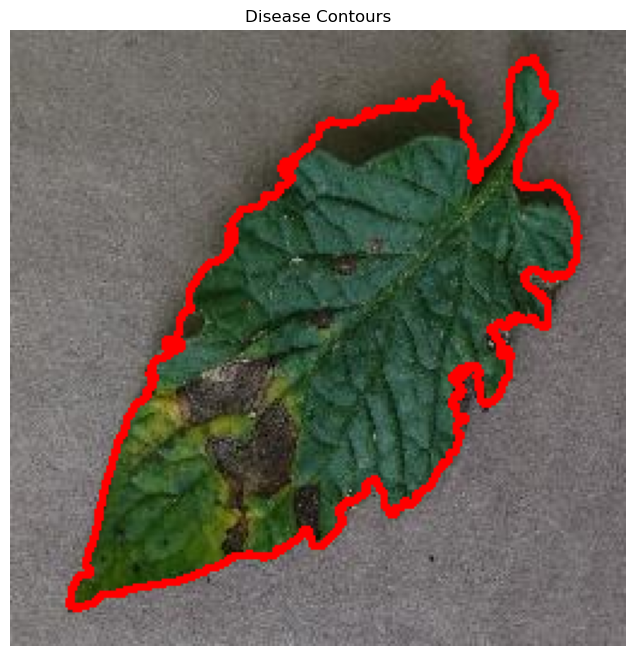

In [20]:
contour_output = image_rgb.copy()

cv2.drawContours(
    contour_output,
    contours,
    -1,
    (255,0,0),
    2
)

plt.figure(figsize=(8,8))
plt.imshow(contour_output)
plt.title("Disease Contours")
plt.axis("off")
plt.show()

# Disease Severity Estimation

Estimate:
infected area percentage

In [22]:
disease_pixels = np.sum(cleaned)

total_pixels = (cleaned.shape[0] * cleaned.shape[1])

severity = (disease_pixels / total_pixels) * 100

print(f"Disease Severity: {severity:.2f}%")

Disease Severity: 36.43%


# Healthy vs Diseased Comparison

Observe:
- cluster homogeneity
- lesion fragmentation
- segmentation behavior

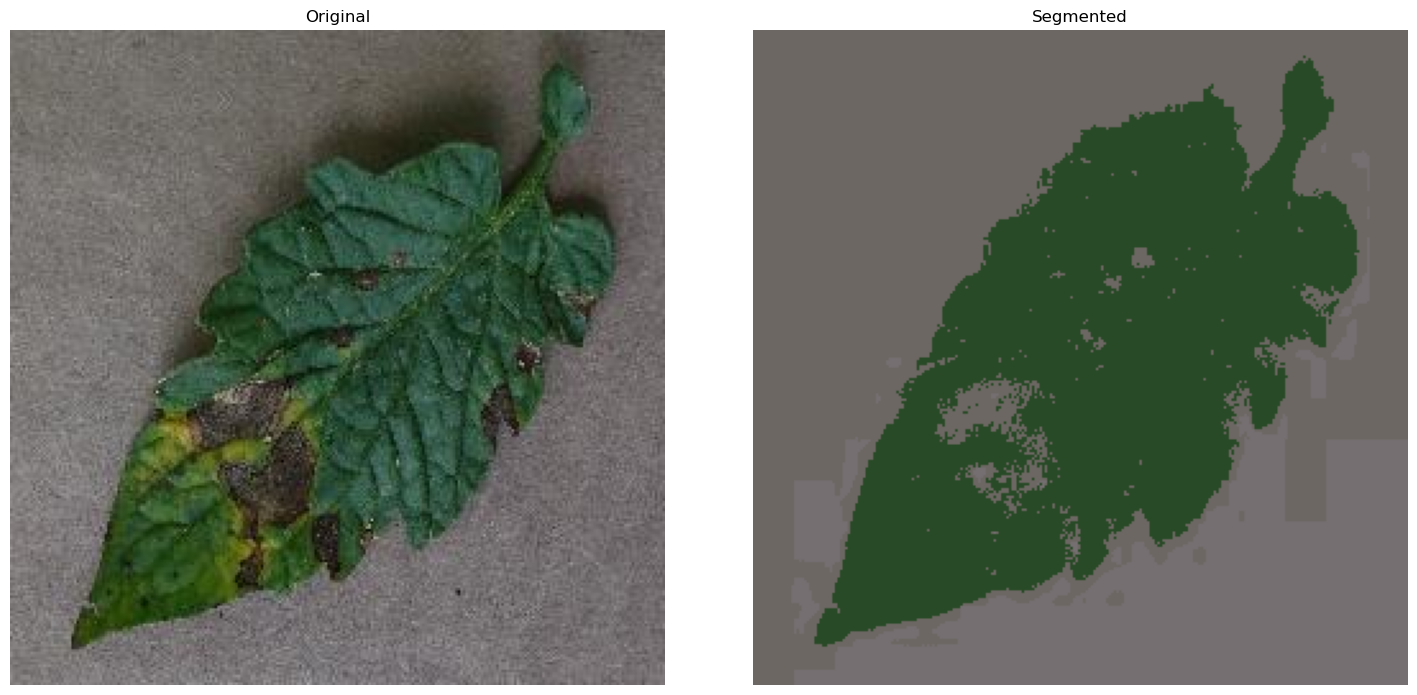

In [24]:
fig, ax = plt.subplots(1,2,figsize=(15,7))

ax[0].imshow(image_rgb)
ax[0].set_title("Original")
ax[0].axis("off")


ax[1].imshow(segmented_rgb)
ax[1].set_title("Segmented")
ax[1].axis("off")

plt.tight_layout()
plt.show()

# Insights & Failure Cases

## Insights

KMeans successfully isolates:
- visually distinct disease regions
- dominant color abnormalities
- lesion structures

Segmentation improves:
- interpretability
- disease localization
- preprocessing quality

---

## Failure Cases

### 1. Lighting Variation
Different illumination changes clustering.

### 2. Wrong K
Too few clusters:
- merges disease

Too many:
- over-fragments image

### 3. Background Leakage
Background colors may merge with lesions.

### 4. Early Disease
Tiny lesions may be missed.

### 5. Shadows
Shadow regions may form separate clusters.

---

KMeans clusters:
- statistical similarity

NOT:
- semantic understanding

# CNN Preprocessing Intuition

This notebook demonstrates:

Classical Computer Vision
→ before →
Deep Learning

Pipeline:

Raw Image
    ↓
Segmentation
    ↓
Disease Isolation
    ↓
CNN Classification

The segmentation process helps:
- remove irrelevant regions
- amplify pathological structure
- improve explainability

Modern CNNs eventually learn:
- edges
- segmentation
- region grouping
implicitly during training.

This notebook reconstructs those primitives manually.

| Concept                    | Covered |
| -------------------------- | ------- |
| HSV color-space            | ✅       |
| manual KMeans              | ✅       |
| clustering dynamics        | ✅       |
| segmentation               | ✅       |
| morphology                 | ✅       |
| contours                   | ✅       |
| severity estimation        | ✅       |
| failure modes              | ✅       |
| preprocessing intelligence | ✅       |
| explainable CV             | ✅       |
